In [1]:
import sys
import os
# sys.path.append('../')
# sys.path.append('../modules/')
# sys.path.append('../util/')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import random
from SFM_Finetune import models_Segmentation
from modules.modeling.deeplab import *
from modules.modeling.Unet_models import *
from util.metrics import *

## data visualization

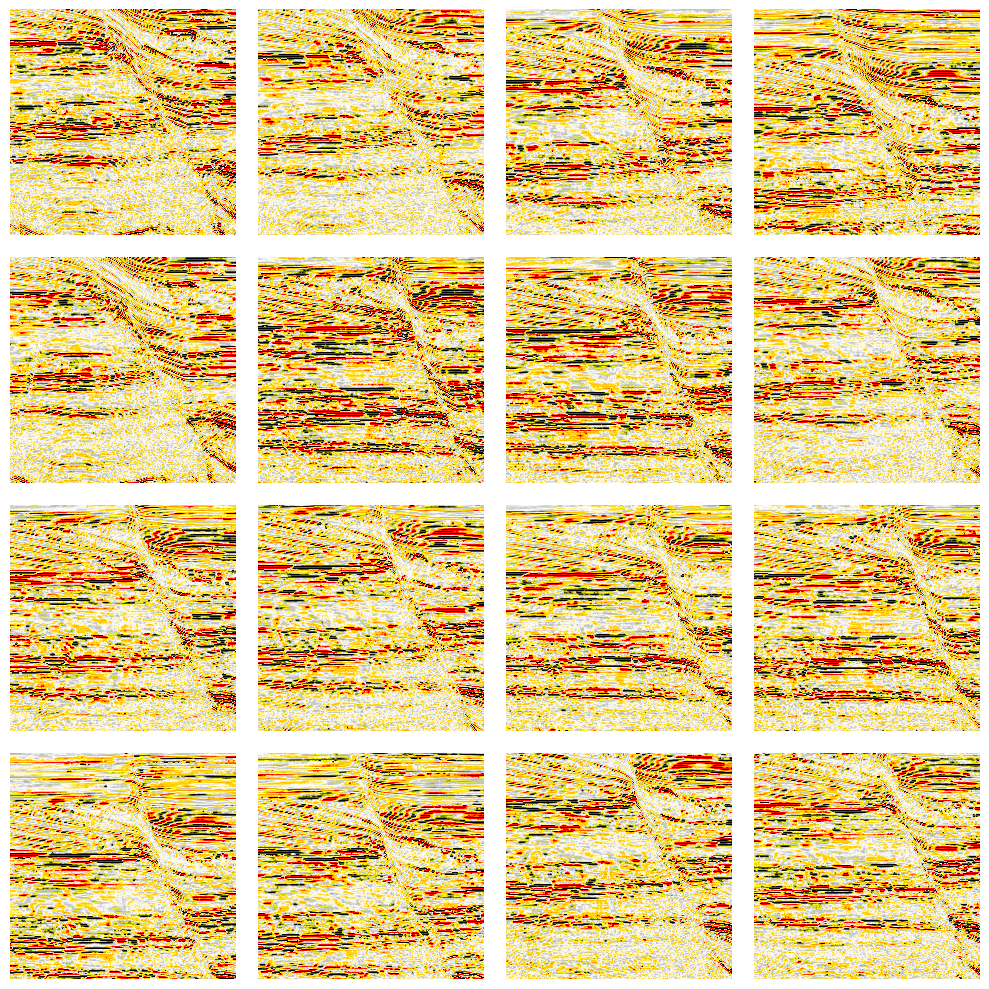

In [2]:
color_list = ['black','yellow','silver','white','gold','orange','red']
cmap = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)


data_path = '/home/zhangji/sdb1_data/Geophysics_data/Data/Facies/' +'seismic/'
label_path = '/home/zhangji/sdb1_data/Geophysics_data/Data/Facies/' +'label/'
data_files =  [str(f)+'.dat' for f in range(100,117)]
selected_files = random.sample(data_files, 16) # Random Select files to show


fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    with open(os.path.join(data_path, selected_files[i]), 'rb') as f:
        data = np.fromfile(f, dtype=np.single)
        data = data.reshape((768, 768))
        ax.imshow(data, cmap=cmap,vmin=np.min(data)/10,vmax=-np.min(data)/10)
        ax.axis('off')
# 显示整个图像
plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

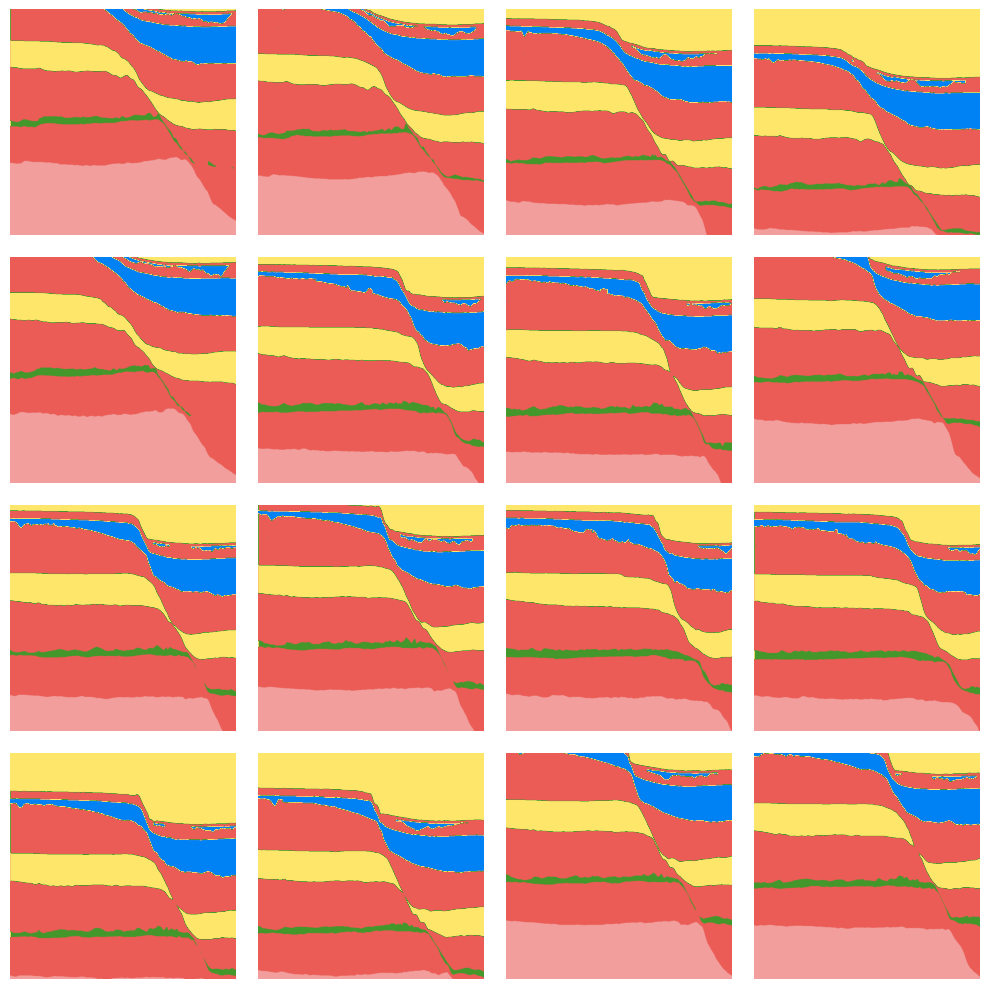

In [3]:
color_list = ['#F19E9C','#EB5C56','#43972B','#FEE76B','#F3B677','#0082F4'] #seam
cmapl = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    with open(os.path.join(label_path, selected_files[i]), 'rb') as f:
        data = np.fromfile(f, dtype=np.single)-1
        data = data.reshape((768, 768))
        ax.imshow(data, cmap=cmapl)#,vmin=np.min(data)/2,vmax=-np.min(data)/2)
        ax.axis('off')
plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()

## Define utils

In [4]:
import matplotlib as mpl
color_list = ['black','yellow','silver','white','gold','orange','red']
cmap = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)

def show_image(image, vmin=None, vmax=None, title='', figsize=None,cmap=None):
    if figsize is not None:
        plt.figure(figsize=figsize)
    if cmap:
        plt.imshow(image, cmap=cmap, interpolation='bicubic', vmin=vmin, vmax=vmax)
    else:
        plt.imshow(image, interpolation='bicubic', vmin=vmin, vmax=vmax)
    plt.title(title)
#     plt.axis('off')
    # plt.show()
    return

In [5]:
def select_least_used_gpu():
    if not torch.cuda.is_available():
        raise RuntimeError("No GPU available.")

    num_gpus = torch.cuda.device_count()
    min_memory_usage = float('inf')
    selected_gpu = None

    for i in range(num_gpus):
        memory_allocated = torch.cuda.memory_allocated(i)
        if memory_allocated < min_memory_usage:
            min_memory_usage = memory_allocated
            selected_gpu = i

    return selected_gpu
select_least_used_gpu()

0

## load Model

In [6]:
def prepare_model(chkpt_dir, arch='vit_large_patch16', img_size=768):
    # 检查是否有可用的GPU
    if torch.cuda.is_available():
        # 获取GPU的数量
        num_gpus = torch.cuda.device_count()
        print(f"Number of GPUs available: {num_gpus}")
    
        # 遍历每个GPU并打印详细信息
        for i in range(num_gpus):
            print(f"GPU {i} details:")
            # 获取GPU的名称
            gpu_name = torch.cuda.get_device_name(i)
            print(f"  Name: {gpu_name}")
            # 获取GPU的计算能力
            gpu_capability = torch.cuda.get_device_capability(i)
            print(f"  Compute Capability: {gpu_capability[0]}.{gpu_capability[1]}")
            # 获取GPU的显存总量
            gpu_memory = torch.cuda.get_device_properties(i).total_memory
            print(f"  Total Memory: {gpu_memory / 1e9:.2f} GB")
            # 获取GPU的当前占用显存
            gpu_current_memory = torch.cuda.memory_allocated(i)
            print(f"  Current Memory Allocated: {gpu_current_memory / 1e9:.2f} GB")
            # 获取GPU的当前缓存显存
            gpu_cached_memory = torch.cuda.memory_reserved(i)
            print(f"  Current Memory Cached: {gpu_cached_memory / 1e9:.2f} GB")

        # 选择内存使用量最小的显卡
        num_gpus = torch.cuda.device_count()
        min_memory_usage = float('inf')
        selected_gpu = None    
        for i in range(num_gpus):
            memory_allocated = torch.cuda.memory_allocated(i)
            if memory_allocated < min_memory_usage:
                min_memory_usage = memory_allocated
                selected_gpu = i
        print("GPU %d is selected." % selected_gpu)
        device = torch.device(f'cuda:{selected_gpu}')
    else:
        print("No GPU available.")
        device = torch.device('cpu')
        
    # if not torch.cuda.is_available():
    #     print("No GPU available.")
    #     device = torch.device('cpu')

    # num_gpus = torch.cuda.device_count()
    # min_memory_usage = float('inf')
    # selected_gpu = None

    # for i in range(num_gpus):
    #     memory_allocated = torch.cuda.memory_allocated(i)
    #     if memory_allocated < min_memory_usage:
    #         min_memory_usage = memory_allocated
    #         selected_gpu = i
    
    # if torch.cuda.is_available():
    #     # 获取所有CUDA设备的当前显存使用情况
    #     allocated_memories = torch.cuda.memory_allocated()
    #     # 初始化最小显存使用量和对应的设备索引
    #     min_memory_used = float('inf')
    #     device_with_min_memory = None
        
    #     # 遍历所有设备，找到使用显存最少的设备
    #     for i in range(torch.cuda.device_count()):
    #         if allocated_memories[i] < min_memory_used:
    #             min_memory_used = allocated_memories[i]
    #             device_with_min_memory = i
                
    #     # 选择使用显存最少的设备
    #     device = torch.device(f'cuda:{device_with_min_memory}')
    #     print(f"选择使用显存最少的设备：cuda:{device_with_min_memory}")
    # else:
    #     print("CUDA 不可用，将使用 CPU。")
    #     device = torch.device('cpu')
    
    # device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
    # device = torch.device('cpu')

    model = getattr(models_Segmentation, arch)(num_classes=6, 
                                      drop_path_rate=0.1, 
                                      in_chans=1, 
                                      img_size=img_size,
                                      global_pool=False,
                                      )
    checkpoint = torch.load(chkpt_dir, map_location=device)
#     interpolate_pos_embed(model, checkpoint['model'])
    msg = model.load_state_dict(checkpoint['model'], strict=False)
    print(msg)
    model.to(device)
    return model 

In [7]:
#load model
chkpt_dir = '/home/zhangji/LLM/Geophysics/output_dir/train_base_A100/finetune_checkpoint-1599/Facies/checkpoint-100.pth' 
model_SFM = prepare_model(chkpt_dir, 'vit_base_patch16', img_size=768)

Number of GPUs available: 2
GPU 0 details:
  Name: NVIDIA GeForce RTX 2080 Ti
  Compute Capability: 7.5
  Total Memory: 11.55 GB
  Current Memory Allocated: 0.00 GB
  Current Memory Cached: 0.00 GB
GPU 1 details:
  Name: NVIDIA GeForce RTX 2080 Ti
  Compute Capability: 7.5
  Total Memory: 11.55 GB
  Current Memory Allocated: 0.00 GB
  Current Memory Cached: 0.00 GB
GPU 0 is selected.
<All keys matched successfully>


In [11]:
print(model_SFM)

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(1, 768, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): Identity()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=False)
        (norm): Identity(

In [15]:
# x = torch.tensor(d).to(next(model_SFM.parameters()).device)
# x = x.unsqueeze(0)
# x = x.unsqueeze(0)
# model_SFM.eval()
# pred = model_SFM(x)
# print(pred.shape)
# pred.argmax(dim=1).shape

torch.Size([1, 6, 768, 768])


torch.Size([1, 768, 768])

In [53]:
def run_one_image(img, model,l):
    color_list = ['#F19E9C','#EB5C56','#43972B','#FEE76B','#F3B677','#0082F4'] #seam
    cmapl = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)
    color_list = ['black','yellow','silver','white','gold','orange','red']
    cmap = mpl.colors.LinearSegmentedColormap.from_list('colormap_name', color_list)
    device = next(model.parameters()).device
    
    x = torch.tensor(img).to(device)
    x = x.unsqueeze(0)
    x = x.unsqueeze(0)
    model.eval()
    pred = model(x)
#     print(pred.shape)
    pred = pred.argmax(dim=1).detach().cpu()
    pred = pred.squeeze(0)
    pred = pred.squeeze(0)
    
    figsize = np.array([25, 10]) * 0.5
    dpi = 300
    fig, axs = plt.subplots(1, 3, figsize=figsize, dpi=dpi, constrained_layout=True)
    axi = axs[0]
    axi.imshow(img , cmap=cmap, interpolation='bicubic', vmin=x.min()/12, vmax=x.max()/12)
    axi.set_title("Seismic")
    axi = axs[1]
    axi.imshow(l   , cmap=cmapl, interpolation='bicubic')
    axi.set_title("Label")
    axi = axs[2]
    axi.imshow(pred, cmap=cmapl, interpolation='bicubic')
    axi.set_title("Predict")
    
    

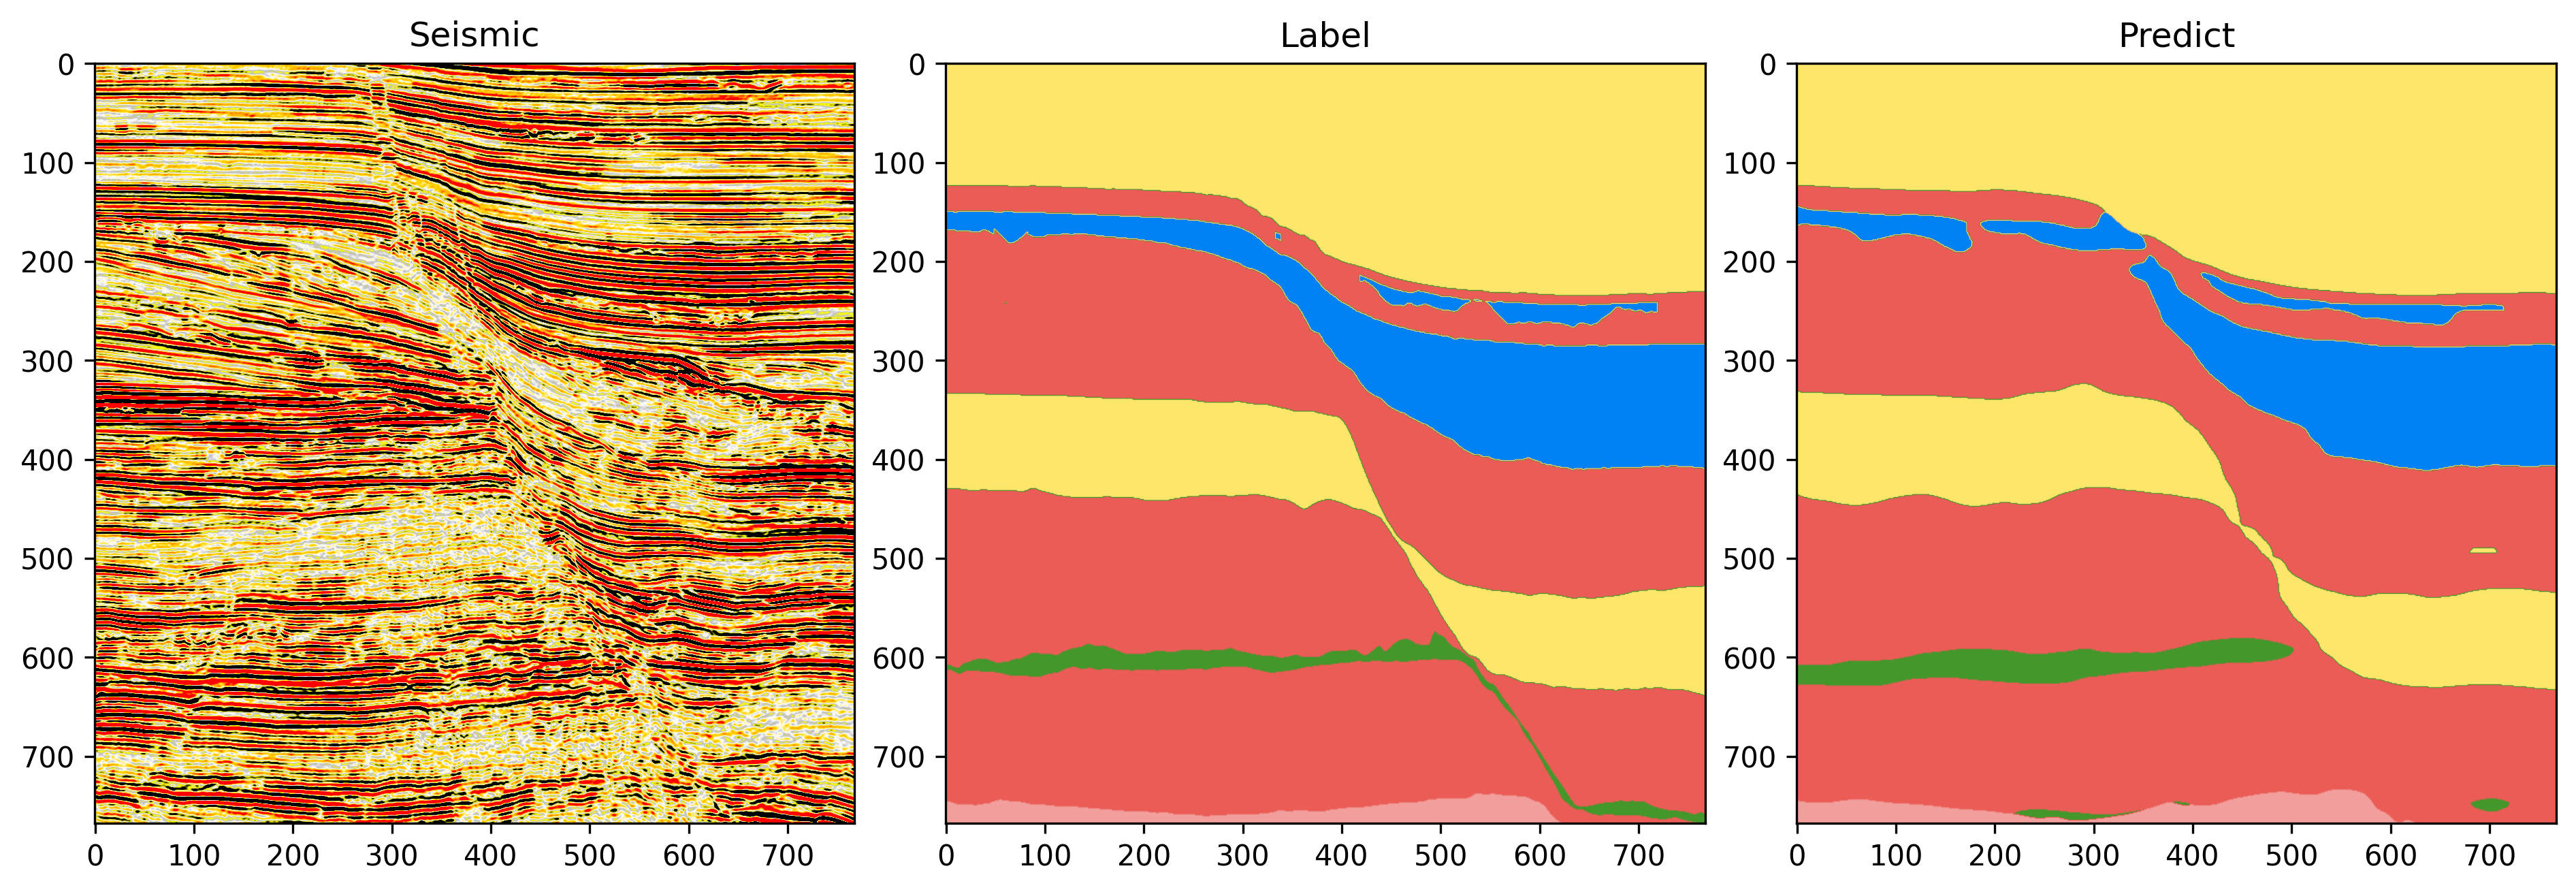

In [54]:
data_list = ['/home/zhangji/sdb1_data/Geophysics_data/Data/Facies/' +'seismic/'+ str(f)+'.dat' for f in range(117)]
label_list = [f.replace('/seismic/', '/label/') for f in data_list]

# dnum = np.random.randint(100, 117) # we use 0-99 as the training dataset and 100-116 as the validation dataset
# print(dnum)
dnum = 103
d = np.fromfile(data_list[dnum], np.float32)
d = d.reshape((768,768))
l = np.fromfile(label_list[dnum], np.float32).reshape([768,768])-1
l = l.astype(int)
run_one_image(d, model_SFM,l)

### Run index

In [14]:
def run_index(img, model, label=None, clims=None, savefig=None):
    device = next(model.parameters()).device
    model.eval()
    
    x = torch.tensor(img, dtype=torch.float32).to(device)
    pred  = model(x)
    pred  = pred.argmax(dim=1).detach().cpu()
    print(pred.shape)
    pred = pred.squeeze(0)
    return pred.numpy()

In [15]:
dd = np.zeros((5, 1, 768, 768))
predall = np.zeros((17, 768, 768)).astype('int64')

# loop through data
for j, start_idx in enumerate(range(100, 115, 5)):
    end_idx = start_idx + 5
    for i in range(start_idx, end_idx):
        d = np.fromfile(data_list[i], np.float32)
        d = d.reshape([1] + [768,768])
        dd[i-start_idx] = d
    # run prediction for current batch
    predall[j*5:j*5+5] = run_index(dd, model_SFM)#model_vit_finetune, model_vit_scartch,model_deeplab,model_unet

# last batch (only has 2 data samples)
dd = np.zeros((2, 1, 768, 768))
for i in range(115, 117):
    d = np.fromfile(data_list[i], np.float32)
    d = d.reshape([1] + [768,768])
    dd[i-115] = d
predall[15:17] = run_index(dd, model_SFM)#model_vit_finetune, model_vit_scartch,model_deeplab,model_unet


torch.Size([5, 768, 768])
torch.Size([5, 768, 768])
torch.Size([5, 768, 768])
torch.Size([2, 768, 768])


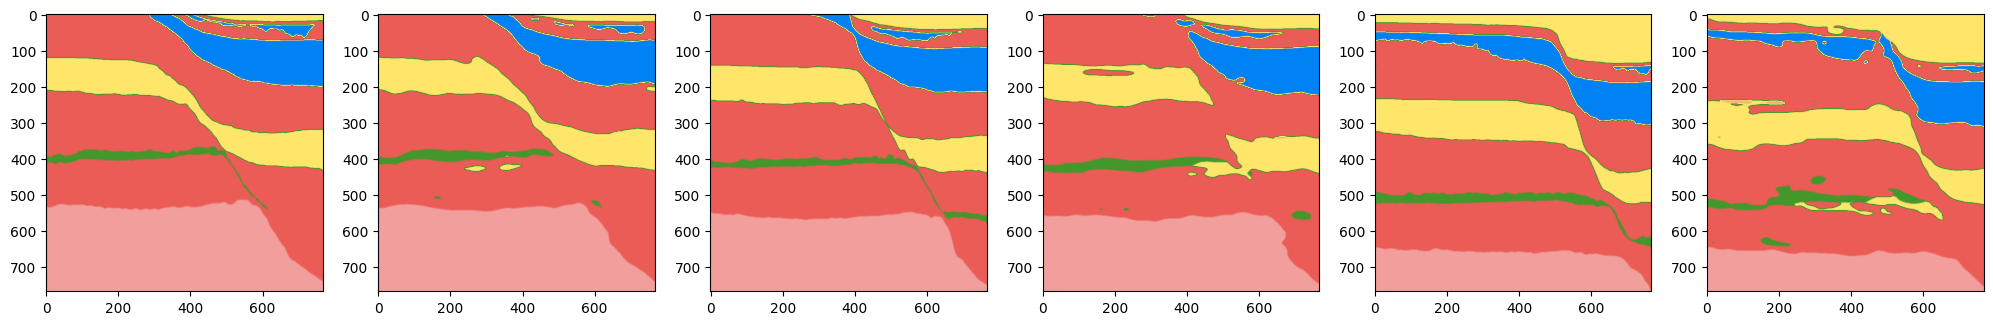

In [16]:
lll = np.zeros((17,768,768)).astype('int32')
for i in range(100,117):
    l = np.fromfile(label_list[i], np.float32).reshape([768,768])-1
    l = l.astype('int32')
    lll[i-100] = l
# predall800 = predall
plt.subplot(1,6,1)
show_image(lll[0],cmap=cmapl, vmin=0, vmax=5)
plt.subplot(1,6,2)
show_image(predall[0], cmap=cmapl, vmin=0, vmax=5)
plt.subplot(1,6,3)
show_image(lll[5], cmap=cmapl, vmin=0, vmax=5)
plt.subplot(1,6,4)
show_image(predall[5],cmap=cmapl, vmin=0, vmax=5)
plt.subplot(1,6,5)
show_image(lll[15],cmap=cmapl, vmin=0, vmax=5)
plt.subplot(1,6,6)
show_image(predall[15],cmap=cmapl, vmin=0, vmax=5)

In [21]:
pa_base_512,cpa_base_512,mpa_base_512,IoU_base_512,mIoU_base_512 = [],[],[],[],[]
metricall = SegmentationMetric(6)  # 2表示有2个分类，有几个分类就填几
for i in range(17):
    histall = metricall.addBatch(predall[i].astype('int64'), lll[i])
    pa_base_512.append(metricall.pixelAccuracy())
    cpa_base_512.append(metricall.classPixelAccuracy())
    mpa_base_512.append(metricall.meanPixelAccuracy())
    IoU_base_512.append(metricall.IntersectionOverUnion())
    mIoU_base_512.append(metricall.meanIntersectionOverUnion())

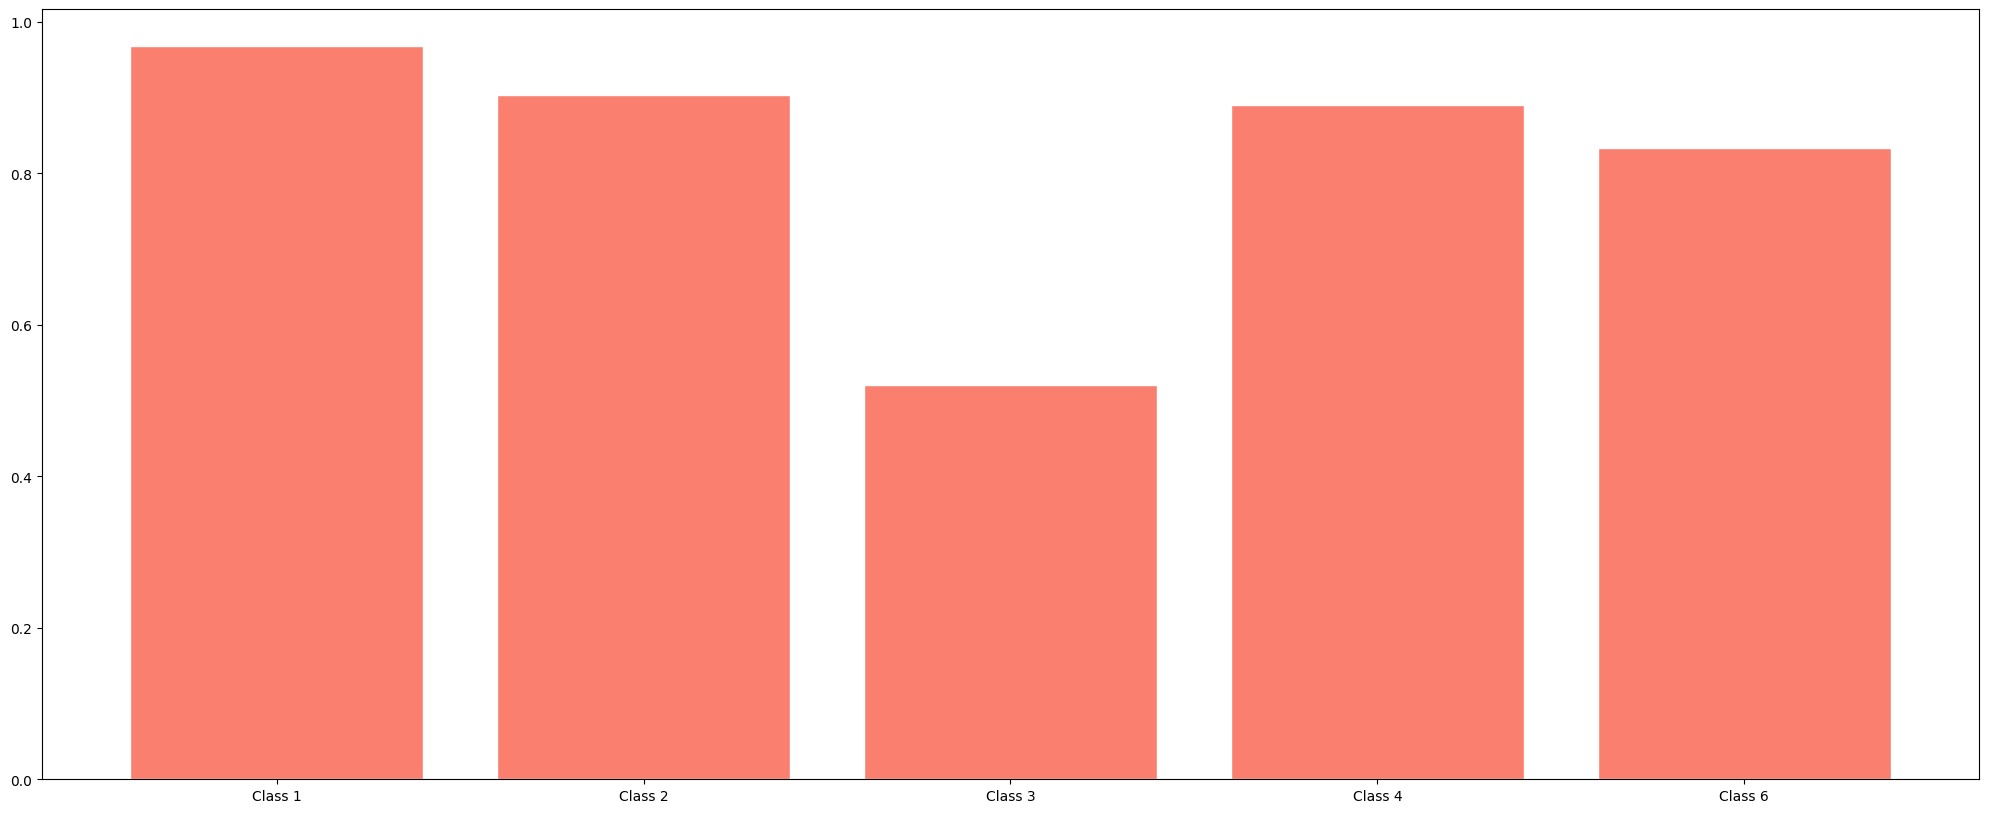

In [22]:
IoU = np.delete(np.mean(IoU_base_512,axis=0),4)
plt.bar(np.arange(5),IoU, color='#FA7F6F', edgecolor='white', label='SFM #512')
plt.xticks(np.arange(5),['Class 1','Class 2','Class 3','Class 4','Class 6'])
plt.show()